In [ ]:
# Install packages (run in a Colab/Kaggle cell)
!pip install -q torch transformers datasets peft accelerate bitsandbytes sentencepiece
!pip install -q --force-reinstall "pyarrow==14.0.2" "datasets==2.20.0"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 45.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 6.1 MB/s eta 0:00:00
ERROR: Cannot install datasets==2.20.0 and pyarrow==14.0.2 because these package versions have conflicting dependencies.
ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts


In [ ]:
# Fixed imports
import os, json, math
from pathlib import Path
from collections import Counter
import torch
import random
import numpy as np

from datasets import Dataset, load_from_disk
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)
from peft import LoraConfig, get_peft_model
from transformers import BitsAndBytesConfig


In [ ]:
FILE_PATH = "/content/improved_smart_tutor_1000plus.json"  # <- change if needed
OUTPUT_DIR = "./phi2_smart_tutor_model"
MODEL_NAME = "microsoft/phi-2"
SEED = 42
MAX_LENGTH = 256
EVAL_SUBSET_SIZE = None

In [ ]:
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

Device: cuda


In [ ]:
path = Path(FILE_PATH)
if not path.exists():
    raise FileNotFoundError(f"File not found: {path}")

with open(path, "r", encoding="utf-8") as f:
    raw = json.load(f)

print("Raw samples:", len(raw))

Raw samples: 772


In [ ]:
seen = {}
unique = []
dup_count = 0
for item in raw:
    msgs = item.get("messages", [])
    combined = " ||| ".join([m.get("role","") + ":" + m.get("content","") for m in msgs])
    if combined in seen:
        dup_count += 1
        continue
    seen[combined] = True
    unique.append(item)

print(f"Deduplicated: removed {dup_count} exact duplicates. Remaining: {len(unique)}")


Deduplicated: removed 74 exact duplicates. Remaining: 698


In [ ]:
records = []
for item in unique:
    user_text = ""
    assistant_text = ""
    for msg in item.get("messages", []):
        if msg.get("role") == "user":
            user_text = msg.get("content","").strip()
        elif msg.get("role") == "assistant":
            assistant_text = msg.get("content","").strip()
    # Skip any empty pairs
    if not user_text or not assistant_text:
        continue
    records.append({"instruction": user_text, "output": assistant_text})

print("After removing empty pairs:", len(records))

After removing empty pairs: 698


In [ ]:
df = Dataset.from_list(records)
# shuffle
df = df.shuffle(seed=SEED)

# 80/10/10 split
split = df.train_test_split(test_size=0.2, seed=SEED)
temp = split["test"].train_test_split(test_size=0.5, seed=SEED)

train_ds = split["train"]
val_ds = temp["train"]
test_ds = temp["test"]

print(f"Split sizes -> Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Split sizes -> Train: 558 | Val: 70 | Test: 70


In [ ]:
if EVAL_SUBSET_SIZE is not None:
    val_ds = val_ds.select(range(min(len(val_ds), EVAL_SUBSET_SIZE)))
    test_ds = test_ds.select(range(min(len(test_ds), EVAL_SUBSET_SIZE)))
    print(f"Using eval subsets size -> Val: {len(val_ds)}, Test: {len(test_ds)}")

In [ ]:
print("Loading tokenizer and model (with 4-bit quant)...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
# ensure pad token exists
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"

bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

Loading tokenizer and model (with 4-bit quant)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/564M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
lora_config = LoraConfig(
    r=16,                      # lower r to be safer for memory; you can increase to 32 if GPU allows
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],  # common targets for causal LM
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()  # sanity

trainable params: 7,864,320 || all params: 2,787,548,160 || trainable%: 0.2821


In [ ]:
def tokenize_fn(examples):
    texts = []
    for instr, out in zip(examples["instruction"], examples["output"]):
        # Combine instruction and output into a single training text
        text = f"Instruct: {instr}\nOutput: {out}{tokenizer.eos_token}"
        texts.append(text)

    # Tokenize the combined text
    enc = tokenizer(
        texts,
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors=None
    )

    # Replace pad_token_id with -100 in labels (so padding is ignored in loss)
    input_ids = enc["input_ids"]
    labels = []
    for seq in input_ids:
        labels.append([tok if tok != tokenizer.pad_token_id else -100 for tok in seq])
    enc["labels"] = labels

    return enc


In [ ]:
print("Tokenizing train...")
tokenized_train = train_ds.map(tokenize_fn, batched=True, remove_columns=train_ds.column_names)
print("Tokenizing val...")
tokenized_val = val_ds.map(tokenize_fn, batched=True, remove_columns=val_ds.column_names)
print("Tokenizing test...")
tokenized_test = test_ds.map(tokenize_fn, batched=True, remove_columns=test_ds.column_names)

Tokenizing train...


Map:   0%|          | 0/558 [00:00<?, ? examples/s]

Tokenizing val...


Map:   0%|          | 0/70 [00:00<?, ? examples/s]

Tokenizing test...


Map:   0%|          | 0/70 [00:00<?, ? examples/s]

In [ ]:
tokenized_train.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_val.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_test.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

In [ ]:
!pip install -q --upgrade transformers==4.44.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 156.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 123.5 MB/s eta 0:00:00


In [ ]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=2,
    num_train_epochs=8,                     # allow more epochs; early stopping will stop early if needed
    learning_rate=2e-4,
    warmup_ratio=0.05,
    fp16=True,
    logging_steps=20,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=3,
    report_to="none",
    seed=SEED,
    push_to_hub=False,
)

In [ ]:
from transformers import Trainer, EarlyStoppingCallback

# Make sure tokenized_train and tokenized_val exist
print(f"Train samples: {len(tokenized_train)} | Val samples: {len(tokenized_val)}")

# Create Trainer object
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("\n🚀 Starting training ... (EarlyStopping patience=2)")
trainer.train()


Train samples: 558 | Val samples: 70

🚀 Starting training ... (EarlyStopping patience=2)


Epoch,Training Loss,Validation Loss
1,0.673500,0.424941
2,0.358000,0.274601
3,0.299000,0.250070
4,0.250700,0.229332
5,0.254700,0.229235
6,0.228600,0.220040
7,0.246700,0.216676
8,0.228600,0.217558


TrainOutput(global_step=1120, training_loss=0.4173926715339933, metrics={'train_runtime': 1386.092, 'train_samples_per_second': 3.221, 'train_steps_per_second': 0.808, 'total_flos': 1.821467071217664e+16, 'train_loss': 0.4173926715339933, 'epoch': 8.0})

In [ ]:
'trainer' in globals()

True

In [ ]:
print("\n🧪 Evaluating on test set with trainer.evaluate() ...")
eval_metrics = trainer.evaluate(eval_dataset=tokenized_test)
print("Eval metrics:", eval_metrics)
test_loss = eval_metrics.get("eval_loss", None)
if test_loss is not None:
    test_ppl = math.exp(test_loss) if test_loss < 100 else float("inf")
    print(f"Test Loss: {test_loss:.4f} | Perplexity: {test_ppl:.2f}")
else:
    print("No eval_loss returned. Check training/eval settings.")


🧪 Evaluating on test set with trainer.evaluate() ...


Eval metrics: {'eval_loss': 0.26793399453163147, 'eval_runtime': 8.1848, 'eval_samples_per_second': 8.552, 'eval_steps_per_second': 1.1, 'epoch': 8.0}
Test Loss: 0.2679 | Perplexity: 1.31


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


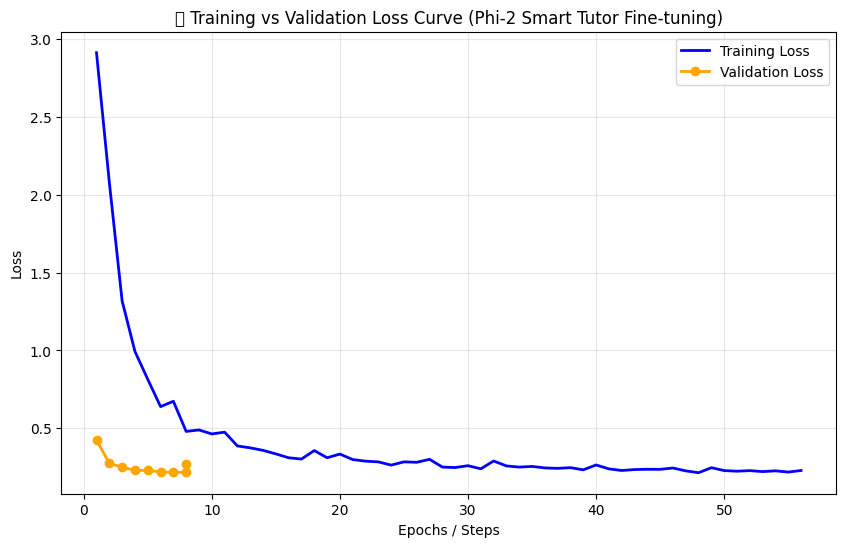

Final Training Loss: 0.2286
Final Validation Loss: 0.2679


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract training and validation logs from the trainer state
logs = trainer.state.log_history

# Collect available metrics
train_loss = [x["loss"] for x in logs if "loss" in x]
eval_loss = [x["eval_loss"] for x in logs if "eval_loss" in x]
epochs = [x["epoch"] for x in logs if "eval_loss" in x]

# Create a smooth x-axis for training loss (may log more frequently than eval)
train_steps = np.linspace(1, len(train_loss), len(train_loss))

# Plot both curves
plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_loss, label="Training Loss", color="blue", linewidth=2)
plt.plot(epochs, eval_loss, label="Validation Loss", color="orange", linewidth=2, marker='o')

plt.title("📉 Training vs Validation Loss Curve (Phi-2 Smart Tutor Fine-tuning)")
plt.xlabel("Epochs / Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print final loss summary
print(f"Final Training Loss: {train_loss[-1]:.4f}")
print(f"Final Validation Loss: {eval_loss[-1]:.4f}")


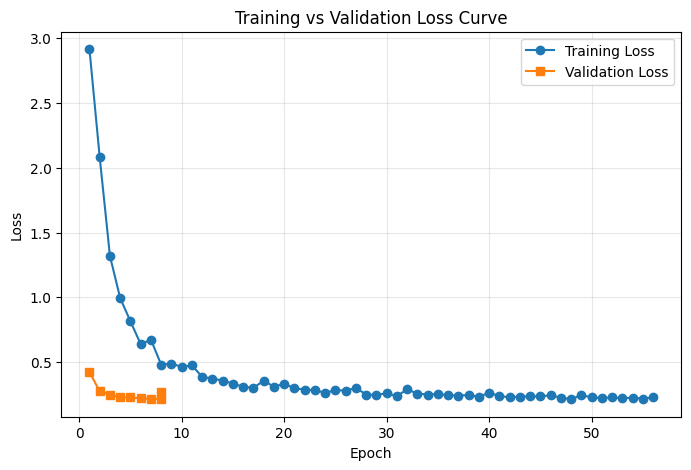

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract logged metrics from trainer
logs = trainer.state.log_history

# Collect losses from logs
train_loss = [x["loss"] for x in logs if "loss" in x and "epoch" in x]
eval_loss = [x["eval_loss"] for x in logs if "eval_loss" in x]
epochs = [x["epoch"] for x in logs if "eval_loss" in x]

# Plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(train_loss)+1), train_loss, label="Training Loss", marker='o')
plt.plot(epochs, eval_loss, label="Validation Loss", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss Curve")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


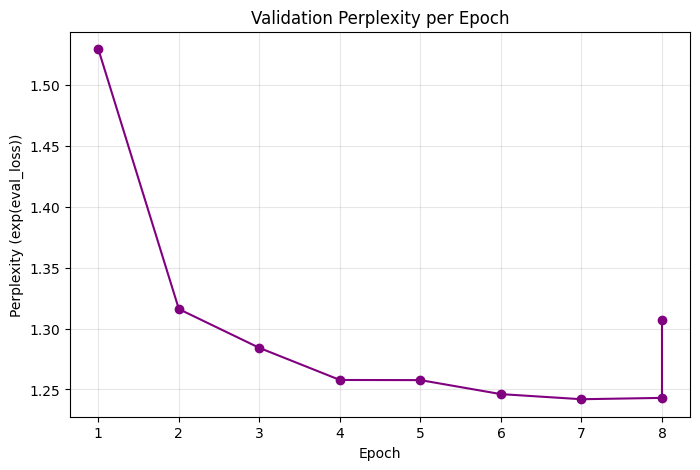

In [ ]:
import matplotlib.pyplot as plt
import math

eval_logs = [x for x in logs if "eval_loss" in x]
epochs = [x["epoch"] for x in eval_logs]
perplexities = [math.exp(x["eval_loss"]) for x in eval_logs]

plt.figure(figsize=(8,5))
plt.plot(epochs, perplexities, marker='o', color='purple')
plt.title("Validation Perplexity per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Perplexity (exp(eval_loss))")
plt.grid(True, alpha=0.3)
plt.show()


100%|██████████| 70/70 [00:08<00:00,  8.34it/s]


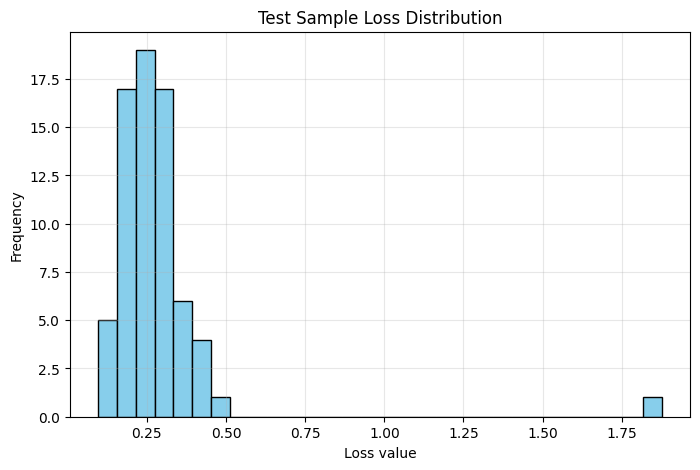

In [ ]:
import numpy as np
from tqdm import tqdm

losses = []
model.eval()

for ex in tqdm(test_ds):
    inputs = tokenizer(
        f"Instruct: {ex['instruction']}\nOutput: {ex['output']}",
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    ).to(model.device)

    with torch.no_grad():
        outputs = model(**inputs, labels=inputs["input_ids"])
        losses.append(outputs.loss.item())

plt.figure(figsize=(8,5))
plt.hist(losses, bins=30, color="skyblue", edgecolor="black")
plt.title("Test Sample Loss Distribution")
plt.xlabel("Loss value")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
print("Saving final model to", OUTPUT_DIR)
# Save PEFT + base quantized weights with adapter config
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

Saving final model to ./phi2_smart_tutor_model


('./phi2_smart_tutor_model/tokenizer_config.json',
 './phi2_smart_tutor_model/special_tokens_map.json',
 './phi2_smart_tutor_model/vocab.json',
 './phi2_smart_tutor_model/merges.txt',
 './phi2_smart_tutor_model/added_tokens.json',
 './phi2_smart_tutor_model/tokenizer.json')

In [ ]:
import shutil

# Path where your model was saved
model_dir = "./phi2_smart_tutor_model"

# Output zip name
zip_path = model_dir + ".zip"

# Remove old zip if it exists
if os.path.exists(zip_path):
    os.remove(zip_path)

# Compress model folder
shutil.make_archive(model_dir, 'zip', model_dir)

print(f"✅ Model zipped successfully: {zip_path}")


✅ Model zipped successfully: ./phi2_smart_tutor_model.zip


In [ ]:
prompt = "Teach me about shapes!"
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=80,
        temperature=0.7,
        top_p=0.9,
        do_sample=True
    )

print("🤖 Smart Tutor:", tokenizer.decode(outputs[0], skip_special_tokens=True))


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


🤖 Smart Tutor: Teach me about shapes!
Output: Awesome! 🎊 Here's a cool thing: shapes!

A circle is round, no corners!
A square has four equal sides!
A triangle has three corners!

Can you see these shapes?

You're a superstar! ✨

Perfect work! 💫

Now, let's try something new!

Brav
